## 1 - Imports and Paths

In [18]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from lexos.dtm import DTM, Vectorizer
from lexos.classification import trainer
from lexos.corpus.corpus_stats import CorpusStats
from lexos.scrubber.scrubber import Scrubber
from lexos.tokenizer import Tokenizer

BASE = Path.cwd()  # Current working directory
DATA = BASE / "fed_papers"

print("Base:", BASE)
print("Data dir exists:", DATA.exists())

Base: c:\Users\gabal\LocalFiles\Lexos_Independant_Research\lexos\doc_src\docs\tutorials\classification
Data dir exists: True


## 2 - Collect Train and Test Filestrain_dirs = ["HAMILTON", "MADISON"]

In [8]:
train_dirs = ["HAMILTON", "MADISON"]
test_dirs = ["COAUTHORED", "DISPUTED"]

train_files = []
for d in train_dirs:
    train_files.extend(sorted((DATA / d).glob("*.txt")))

test_files = []
for d in test_dirs:
    test_files.extend(sorted((DATA / d).glob("*.txt")))

print("Train files:", len(train_files), "Test files:", len(test_files))
assert train_files and test_files, "No files found; check working directory and folder structure."

Train files: 65 Test files: 15


### 2.1 - Sort Files by Filename

In [9]:
train_files = sorted(train_files, key=lambda x: x.name)
test_files = sorted(test_files, key=lambda x: x.name)

## 3 - Scrubber + Tokenizer

In [10]:
scrubber = Scrubber()
scrubber.add_pipe("lower_case")
scrubber.add_pipe("digits")
scrubber.add_pipe("punctuation")

tokenizer = Tokenizer(model="en_core_web_sm")  # or any installed model

## 4 - Build Docs for CorpusStats (Train + Test)

In [11]:
docs_for_corpus_stats = []  # For CorpusStats
docs_for_dtm = []  # For DTM
raw_texts = []
sets_list = []
all_files = [*train_files, *test_files]

for f in all_files:
    raw = f.read_text(encoding="utf-8")
    clean = scrubber.scrub(raw)
    spacy_doc = tokenizer(clean)
    tokens = [t.text for t in spacy_doc if t.text.strip()]
    doc_id = f.name
    docs_for_corpus_stats.append((doc_id, doc_id, tokens))
    docs_for_dtm.append(tokens)  # DTM does not accept tuples
    raw_texts.append(raw)  # Enables char_count if CorpusStats uses raw_texts
    sets_list.append(f.parent.name)

# Generate CorpusStats


### 4.1 - Generate CorpusStats

In [12]:
stats = CorpusStats(docs=docs_for_corpus_stats, raw_texts=raw_texts)
stats_df = stats.doc_stats_df.copy()
stats_df.insert(0, "document_set", sets_list)

## 5 - Generating DTM

In [13]:
vectorizer = Vectorizer(max_features=500)  # Adjust max_features as needed
dtm = DTM(vectorizer=vectorizer)  # Initialize DTM with the vectorizer
dtm(docs=docs_for_dtm, labels=[doc[0] for doc in docs_for_dtm])  # Call the DTM object with docs and labels
dtm_df = pd.DataFrame(dtm.doc_term_matrix.toarray(), columns=dtm.sorted_terms_list)

## 6 - Combine CorpusStats Features with DTM Features

In [14]:
# Reset indices to ensure alignment
stats_df = stats_df.reset_index(drop=True)
dtm_df = dtm_df.reset_index(drop=True)

# Combine the DataFrames
combined_df = pd.concat([stats_df, dtm_df], axis=1)

print("Shape of dtm_df:", dtm_df.shape)
print("Shape of stats_df:", stats_df.shape)
print("Shape of combined_df:", combined_df.shape)

Shape of dtm_df: (80, 8568)
Shape of stats_df: (80, 6)
Shape of combined_df: (80, 8574)


## 7 - Train Classifier

In [15]:
# Select feature columns from combined_df
feature_cols = [
    "hapax_legomena",
    "total_tokens",
    "total_terms",
    "vocabulary_density",
    "hapax_dislegomena",
] + list(dtm_df.columns)

# Extract features and labels
X = combined_df[feature_cols].values
y = combined_df["document_set"].values

# Train the classifier using train_classifier()
clf, report = trainer.train_classifier(
    feature_matrix=X,
    target_labels=y,
    model="decision_tree",
    test_size=0.3,  # 30% test data
    random_state=42,
    normalize="standard"  # Apply StandardScaler
)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

  COAUTHORED       0.00      0.00      0.00         1
    DISPUTED       0.40      0.50      0.44         4
    HAMILTON       0.86      0.80      0.83        15
     MADISON       0.20      0.25      0.22         4

    accuracy                           0.62        24
   macro avg       0.36      0.39      0.37        24
weighted avg       0.64      0.62      0.63        24



c:\Users\gabal\LocalFiles\Lexos_Independant_Research\lexos\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gabal\LocalFiles\Lexos_Independant_Research\lexos\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gabal\LocalFiles\Lexos_Independant_Research\lexos\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beh

## 8 - Feature Importance

,feature,importance
8171,upon,0.525011
5397,once,0.207047
7957,two,0.113673
1067,can,0.109613
422,anew,0.044657
...,...,...
8552,wyoming,0.000000
8553,xerxes,0.000000
8554,xiv,0.000000
8555,yates,0.000000


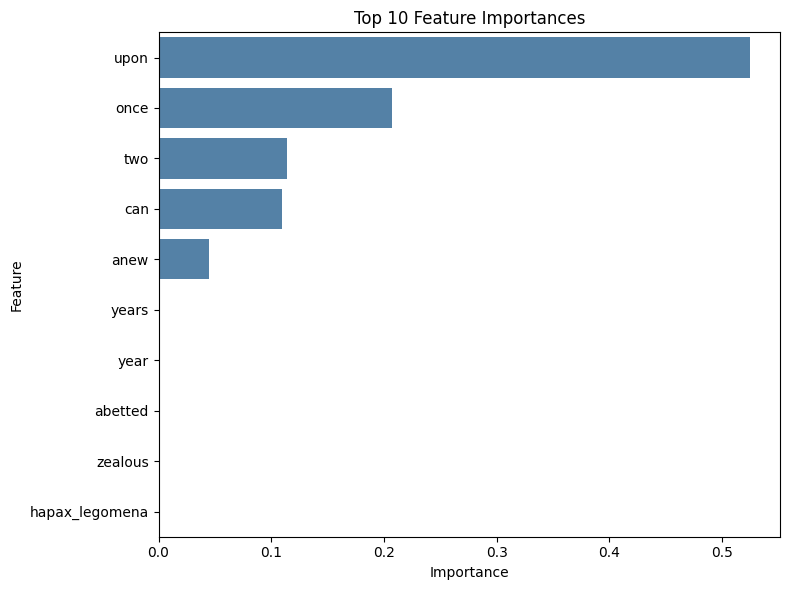

In [21]:
# Get feature importances
imp = clf.feature_importances_

# Create a DataFrame for feature importances
imp_df = pd.DataFrame({"feature": feature_cols, "importance": imp}).sort_values("importance", ascending=False)

# Display the DataFrame
display(imp_df)

# Select the top 10 features
top_10_features = imp_df.head(10)

# Plot the top 10 feature importances
plt.figure(figsize=(8, 6))
sns.barplot(data=top_10_features, x="importance", y="feature", color="steelblue")
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 9 - Predictions and Evaluation on Test Set

In [20]:
# Predict labels on the test set
y_pred_test = clf.predict(X)

# Create prediction DataFrame
pred_df = pd.DataFrame({
    "doc_id": combined_df.index,
    "set": combined_df["document_set"].values,
    "pred_author": y_pred_test
})

print("Predictions on Test Set:")
display(pred_df)

# Count predictions by document set
print("\nPrediction Summary:")
print(pred_df.groupby(["set", "pred_author"]).size().unstack(fill_value=0))

Predictions on Test Set:


,doc_id,set,pred_author
0,0,MADISON,HAMILTON
1,1,HAMILTON,HAMILTON
2,2,HAMILTON,HAMILTON
3,3,HAMILTON,HAMILTON
4,4,MADISON,HAMILTON
...,...,...,...
75,75,DISPUTED,HAMILTON
76,76,DISPUTED,HAMILTON
77,77,DISPUTED,HAMILTON
78,78,DISPUTED,HAMILTON



Prediction Summary:
pred_author  HAMILTON
set                  
COAUTHORED          3
DISPUTED           12
HAMILTON           51
MADISON            14
